# Calculation general flare distributions in viewing angle $\mu$

Load dependicies

In [1]:
import numpy as np
import scipy.special as sc
import matplotlib.pyplot as plt
from scipy.integrate import quad


Specificy the overall 3D-distribution for active regions and flares on a star (here we used the fit of experimental_flare_distribuition.ipynb of the Sun). 
We assume this only depends upon the lattitude $\alpha$.

In [2]:
# general distribution for area 
def rice_dist(x, sigma, nu):
    x = np.abs(x)
    return x / sigma**2 * np.exp( - (x**2 + nu **2 ) / (2 * sigma **2)) * sc.iv(0, (x * nu / sigma**2))

sigma_fit, nu_fit = (9.02769086 / 180 * np.pi, 10.48768514 / 180 * np.pi)

def rho(alpha, err=0.01):
    return rice_dist(np.pi / 2 - alpha, sigma_fit, nu_fit) / 2 / np.pi / (np.sin(alpha) + err) / 2 
            # fit of dist when integrated over phi and absolute value so accounting for that

display the distribution as a function of lattitude $\alpha$

Text(0.5, 1.0, 'Distribution of ')

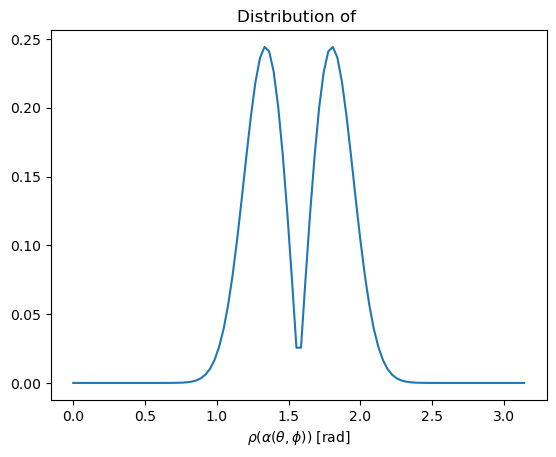

In [3]:
alpha = np.linspace(0, np.pi, 100)
plt.plot(alpha, rho(alpha))
plt.xlabel(r"$\alpha(\theta, \phi)$ [rad]")
plt.xlabel(r"$\rho(\alpha(\theta, \phi))$ [rad]")
plt.title('Distribution of ')

In [4]:
# f = lambda x: rice_dist(x, sigma_fit, nu_fit)


# quad(f,0, np.pi)

Therefore density as a function of $\mu$ is $$\rho_\mu(\mu) = 2 \int_{[0, 2\pi]}d\phi \rho (\alpha(\theta, \phi))
.$$
where
$$
\cos \alpha = \sin \tau \sin \theta \cos \phi +\cos \theta \cos \tau  $$
and $\mu = \cos \theta$. (For all symbols we refer to the associated paper.)

We now calculate the distribution in $\mu$ for a given angle $\tau$

In [36]:
# general distribution in mu for given tau
def get_alpha(tau, theta, phi):
    return np.arccos( np.sin( tau ) * np.sin(theta) * np.cos(phi) + np.cos(tau) * np.cos(theta))

def rho_mu(mu, tau):
    theta = np.arccos(mu)
    I = lambda phi: rho(get_alpha(tau, theta, phi))
    return 2 * quad(I, 0, 2*np.pi)[0] 

def rho_mus(mus, tau):
    return [ rho_mu(mu,tau) for mu in mus]
    


0.0 (0.9896632430611714, 4.727765598241539e-14)
0.39269908169872414 (0.989663237218806, 9.637162925000425e-09)
0.7853981633974483 (0.9896632413563907, 4.110435339370042e-09)
1.1780972450961724 (0.9896632373627069, 1.0451195036800443e-09)
1.5707963267948966 (0.9896632430612415, 5.93999038844828e-09)


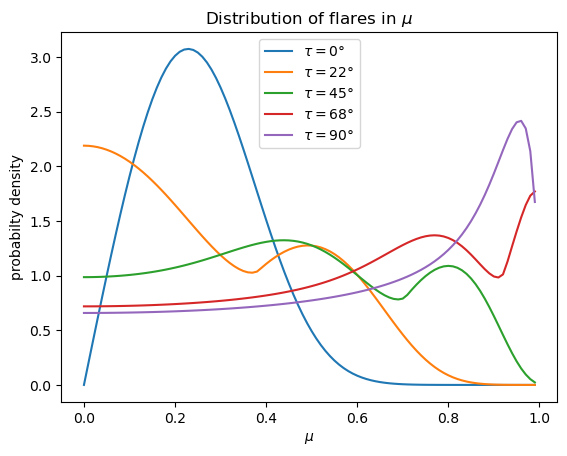

In [38]:
rho_mu_of_tau = lambda tau : lambda mu : rho_mu(mu, tau)

# def rho_mus2(mus, tau):
#     return [ rho_mu(mu,tau) * (1-mu**2)**0.5 for mu in mus]

mu = np.linspace(0,0.99, 100)

for tau in np.linspace(0,np.pi/2, 5):
    plt.plot(mu, rho_mus(mu, tau), label=fr'$\tau=${round(tau*180/np.pi)}°')
    print(tau, quad(rho_mu_of_tau(tau), 0, 1))

# plt.ylim(0,1)
plt.title(r"Distribution of flares in $\mu$")
plt.xlabel(r"$\mu$")
plt.ylabel("probabilty density")
plt.legend()

# Different distribution assumption: normal distribution around equator

Text(0, 0.5, 'probability density per unit area')

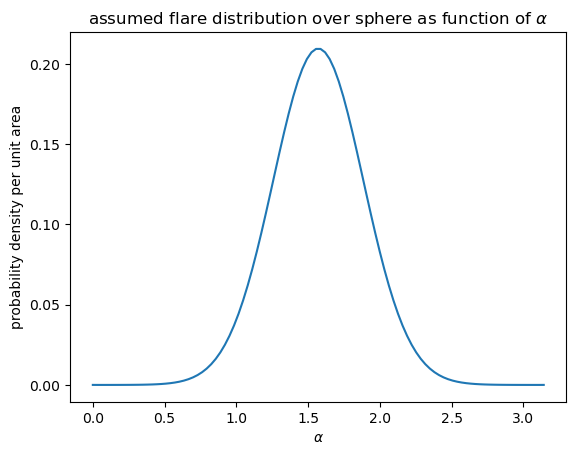

In [7]:
from scipy.stats import norm

def rho(alpha, loc=np.pi/2, scale = 0.3, err = 0.01):
    return norm.pdf(alpha, loc, scale) / 2 / np.pi / (np.sin(alpha) + err) 

alpha = np.linspace(0, np.pi, 100)
plt.plot(alpha, rho(alpha))
plt.title(r"assumed flare distribution over sphere as function of $\alpha$")
plt.xlabel(r"$\alpha$")
plt.ylabel('probability density per unit area')

0.0 (0.9895962000276162, 5.042964046353404e-09)
0.39269908169872414 (0.9895961988532547, 1.516983175045775e-09)
0.7853981633974483 (0.9895962002095553, 4.501296178332404e-09)
1.1780972450961724 (0.9895961876136867, 4.098245470594385e-09)
1.5707963267948966 (0.989596200117882, 1.343628143600427e-11)


C:\Users\mdewilde\AppData\Local\Temp\ipykernel_3612\3811857004.py:8: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return 2 * quad(I, 0, 2*np.pi)[0]


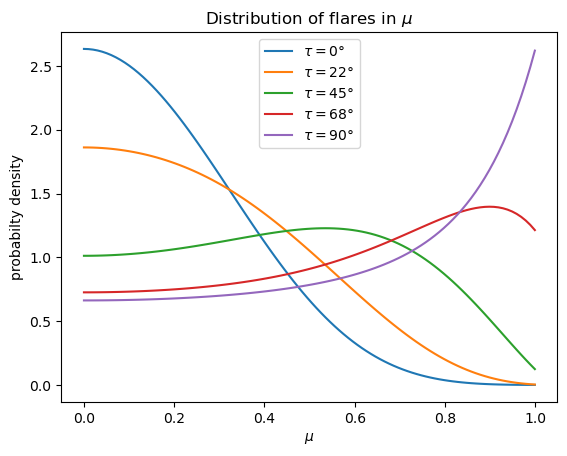

In [8]:
# rho_mu_of_tau = lambda tau : lambda mu : rho_mu(mu, tau)* (1-mu**2)**0.5

# def rho_mus2(mus, tau):
#     return [ rho_mu(mu,tau) * (1-mu**2)**0.5 for mu in mus]

mu = np.linspace(0,0.999, 100)

for tau in np.linspace(0,np.pi/2, 5):
    plt.plot(mu, rho_mus(mu, tau), label=fr'$\tau=${round(tau*180/np.pi)}°')
    print(tau, quad(rho_mu_of_tau(tau), 0, 1))

# plt.ylim(0,5)
plt.title(r"Distribution of flares in $\mu$")
plt.xlabel(r"$\mu$")
plt.ylabel("probabilty density")
plt.legend()

## uniform distribution

Text(0, 0.5, 'probability density per unit area')

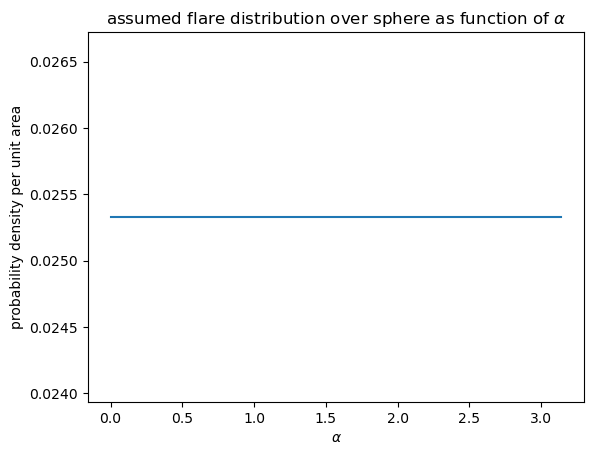

In [10]:
def rho(alpha, loc=np.pi/2, scale = 0.5):
    return alpha * 0 + 1 / np.pi**2 / 4 

alpha = np.linspace(0, np.pi, 100)
plt.plot(alpha, rho(alpha))
plt.title(r"assumed flare distribution over sphere as function of $\alpha$")
plt.xlabel(r"$\alpha$")
plt.ylabel('probability density per unit area')

0.0 (0.3183098861837907, 3.5339496460705744e-15)
0.39269908169872414 (0.3183098861837907, 3.5339496460705744e-15)
0.7853981633974483 (0.3183098861837907, 3.5339496460705744e-15)
1.1780972450961724 (0.3183098861837907, 3.5339496460705744e-15)
1.5707963267948966 (0.3183098861837907, 3.5339496460705744e-15)


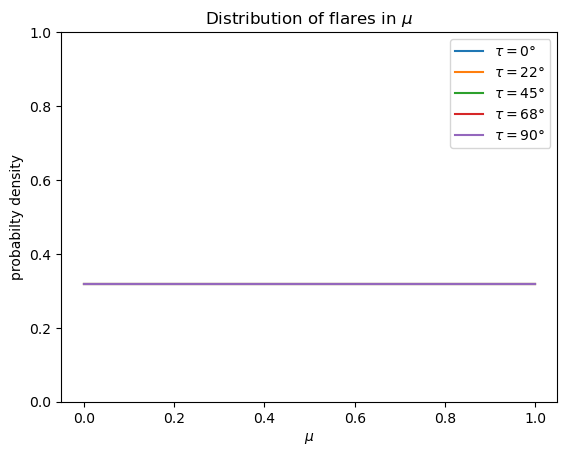

In [11]:
# rho_mu_of_tau = lambda tau : lambda mu : rho_mu(mu, tau)* (1-mu**2)**0.5

# def rho_mus2(mus, tau):
#     return [ rho_mu(mu,tau) * (1-mu**2)**0.5 for mu in mus]

mu = np.linspace(0,0.999, 100)

for tau in np.linspace(0,np.pi/2, 5):
    plt.plot(mu, rho_mus(mu, tau), label=fr'$\tau=${round(tau*180/np.pi)}°')
    print(tau, quad(rho_mu_of_tau(tau), 0, 1))

plt.ylim(0,1)
plt.title(r"Distribution of flares in $\mu$")
plt.xlabel(r"$\mu$")
plt.ylabel("probabilty density")
plt.legend()

# Flares in uniform band around equator

Text(0, 0.5, 'probability density per unit area')

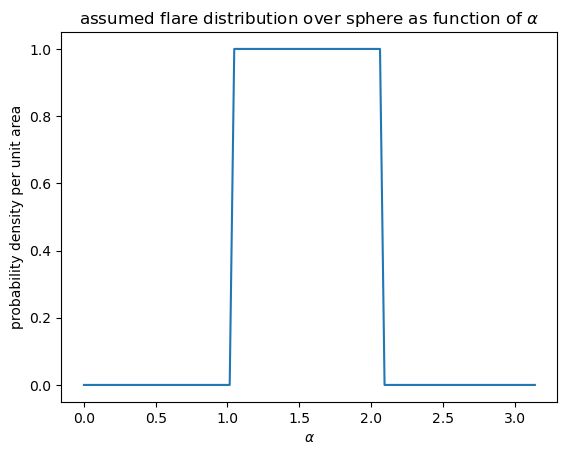

In [12]:
def rho(alpha, h=30/180*np.pi):
    return np.where(np.abs(alpha-np.pi/2) < h, 1, 0)


alpha = np.linspace(0, np.pi, 100)
plt.plot(alpha, rho(alpha))
plt.title(r"assumed flare distribution over sphere as function of $\alpha$")
plt.xlabel(r"$\alpha$")
plt.ylabel('probability density per unit area')

C:\Users\mdewilde\AppData\Local\Temp\ipykernel_3612\3811857004.py:8: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return 2 * quad(I, 0, 2*np.pi)[0]


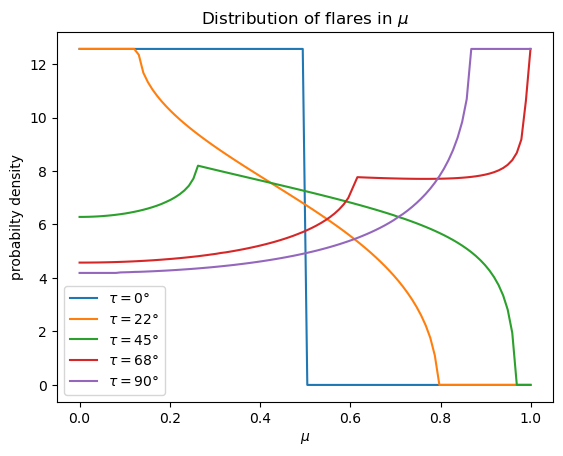

In [13]:
# rho_mu_of_tau = lambda tau : lambda mu : rho_mu(mu, tau)* (1-mu**2)**0.5

# def rho_mus2(mus, tau):
#     return [ rho_mu(mu,tau) * (1-mu**2)**0.5 for mu in mus]

mu = np.linspace(0,0.999, 100)

for tau in np.linspace(0,np.pi/2, 5):
    plt.plot(mu, rho_mus(mu, tau), label=fr'$\tau=${round(tau*180/np.pi)}°')
    # print(tau, quad(rho_mu_of_tau(tau), 0, 1))

# plt.ylim(0,1)
plt.title(r"Distribution of flares in $\mu$")
plt.xlabel(r"$\mu$")
plt.ylabel("probabilty density")
plt.legend()

## Flare at the poles! (normal distribution)

Text(0, 0.5, 'probability density per unit area')

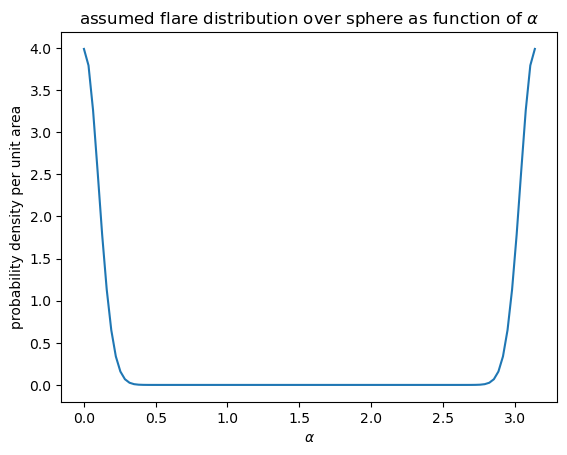

In [37]:
from scipy.stats import norm
# normalization, later to be determined

N = 1

def rho(alpha, loc=0, scale = 0.1):
    return (norm.pdf(alpha, loc, scale) + norm.pdf(alpha, loc+np.pi, scale)) /N

# N = quad(lambda a :  rho(a), 0, np.pi/2)[0]


alpha = np.linspace(0, np.pi, 100)
plt.plot(alpha, rho(alpha))
plt.title(r"assumed flare distribution over sphere as function of $\alpha$")
plt.xlabel(r"$\alpha$")
plt.ylabel('probability density per unit area')

0.0 (0.4996579068115824, 1.823595264204681e-12)
0.39269908169872414 (0.49965790681158184, 8.471121273979013e-14)
0.7853981633974483 (0.4996579068115845, 3.954248096020856e-11)
1.1780972450961724 (0.4996579068115831, 8.763436795677926e-09)
1.5707963267948966 (0.4996579068115795, 6.359449464428402e-10)


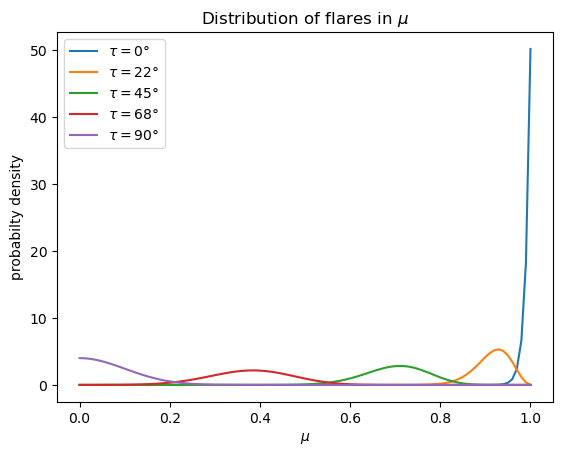

In [38]:
# general distribution in mu for given tau
def get_alpha(tau, theta, phi):
    return np.arccos( np.sin( tau ) * np.sin(theta) * np.cos(phi) + np.cos(tau) * np.cos(theta))

def rho_mu(mu, tau):
    theta = np.arccos(mu)
    I = lambda phi: rho(get_alpha(tau, theta, phi)) 
    return 2 * quad(I, 0, 2*np.pi)[0]

def rho_mus(mus, tau):
    return [ rho_mu(mu,tau) for mu in mus]
    
rho_mu_of_tau = lambda tau : lambda mu : rho_mu(mu, tau) # * (1-mu**2)**0.5


mu = np.linspace(0,1, 100)

for tau in np.linspace(0,np.pi/2, 5):
    plt.plot(mu, rho_mus(mu, tau), label=fr'$\tau=${round(tau*180/np.pi)}°')
    print(tau, quad(rho_mu_of_tau(tau), 0, 1))

# plt.ylim(0,5)
plt.title(r"Distribution of flares in $\mu$")
plt.xlabel(r"$\mu$")
plt.ylabel("probabilty density")
plt.legend()

There are flares leaking away under the equator